# baseline_v2_multiclass — results analysis

Analysis of the 7-class farm-type classifier trained on Rachel's clusters (5 main countries + 48 long-tail inspected, with country + class balanced sampling).

**Class taxonomy:**

| id | name | train n |
|---:|---|---:|
| 0 | NotFarm | 3,104 |
| 1 | Poultry: Meat Chickens | 2,258 |
| 2 | Poultry: Eggs | 550 |
| 3 | Poultry: Unspecified/Other | 5,481 |
| 4 | Pigs | 1,638 |
| 5 | Cattle | 75 (25.76× oversampled) |
| 6 | Other (Mixed/Unknown/PigsOrPoultry) | 419 |

**Analyses below:**
1. Headline metrics (test + inspected)
2. Per-split label distributions
3. **Full 7-class confusion matrix**
4. **5-class confusion matrix** (poultry sub-classes collapsed)
5. **3-class confusion matrix** (NotFarm / Poultry / OtherFarm)
6. Per-country generalization
7. Confidence calibration

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

ROOT = Path('..').resolve()
OUT = ROOT / 'data/output/baseline_v2_multiclass'

scored = pd.read_parquet(OUT / 'scored_candidates.parquet')
with open(OUT / 'training_metrics.json') as f:
    test_metrics = json.load(f)
with open(OUT / 'inspected_metrics.json') as f:
    insp_metrics = json.load(f)

NAMES_7 = ['NotFarm', 'Poultry-Meat', 'Poultry-Eggs', 'Poultry-Unspec',
           'Pigs', 'Cattle', 'Other']

print(f'Total scored: {len(scored):,}')
print(f'Splits: {scored["split"].value_counts().to_dict()}')
print()
print('Test metrics (random val/test, country-balanced):')
print(json.dumps(test_metrics, indent=2))
print()
print('Inspected metrics (5 main + 48 long-tail):')
print(json.dumps(insp_metrics, indent=2))

Total scored: 15,489
Splits: {'train': 13525, 'inspected': 1464, 'val': 250, 'test': 250}

Test metrics (random val/test, country-balanced):
{
  "accuracy": 0.516,
  "precision": 0.4128,
  "recall": 0.4248,
  "f1": 0.3968,
  "f1_class0": 0.8113,
  "f1_class1": 0.4444,
  "f1_class2": 0.3333,
  "f1_class3": 0.5536,
  "f1_class4": 0.4348,
  "f1_class5": 0.0,
  "f1_class6": 0.2,
  "loss": 1.271973
}

Inspected metrics (5 main + 48 long-tail):
{
  "accuracy": 0.2678,
  "precision": 0.3502,
  "recall": 0.2481,
  "f1": 0.2395,
  "f1_class0": 0.5669,
  "f1_class1": 0.0,
  "f1_class2": 0.0151,
  "f1_class3": 0.1737,
  "f1_class4": 0.3931,
  "f1_class5": 0.4653,
  "f1_class6": 0.0625,
  "loss": 2.076575
}


## 1. Per-split label distributions

The split shapes matter for reading the confusion matrices — especially that **test** has only 250 samples (5 countries × 50/country) so per-class support is tiny, while **inspected** has 1,464 with a very different class distribution from train.

In [2]:
rows = []
for sp in ('train', 'val', 'test', 'inspected'):
    sub = scored[scored['split'] == sp]
    counts = sub['true_label'].value_counts().sort_index()
    row = {'split': sp, 'n': len(sub)}
    for c in range(7):
        row[NAMES_7[c]] = int(counts.get(c, 0))
    rows.append(row)
dist = pd.DataFrame(rows).set_index('split')
dist

,n,NotFarm,Poultry-Meat,Poultry-Eggs,Poultry-Unspec,Pigs,Cattle,Other
split,,,,,,,,
train,13525,3104,2258,550,5481,1638,75,419
val,250,57,60,26,63,38,2,4
test,250,55,63,22,69,37,1,3
inspected,1464,400,1,10,566,281,96,110


In [3]:
# Same as fractions per split — easier to compare
frac = dist.drop(columns=['n']).div(dist['n'], axis=0).round(3)
frac

,NotFarm,Poultry-Meat,Poultry-Eggs,Poultry-Unspec,Pigs,Cattle,Other
split,,,,,,,
train,0.230,0.167,0.041,0.405,0.121,0.006,0.031
val,0.228,0.240,0.104,0.252,0.152,0.008,0.016
test,0.220,0.252,0.088,0.276,0.148,0.004,0.012
inspected,0.273,0.001,0.007,0.387,0.192,0.066,0.075


Key observation: the **train** distribution has 35.4 % Poultry-Unspec and only 2.4 % Cattle. **Inspected** is 38.7 % Poultry-Unspec, 6.6 % Cattle, but the meat/eggs/unspec split is wildly different from train (Meat=0.07 %, Eggs=0.7 %). That's the structural reason the 3-way poultry split breaks down at evaluation time.

## 2. Helper functions

In [4]:
def plot_cm(y_true, y_pred, labels, names, title, ax=None, normalize='true'):
    """Annotated confusion matrix heatmap. normalize='true' = row-stochastic (recall view)."""
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize=normalize)
    n_cm = confusion_matrix(y_true, y_pred, labels=labels, normalize=None)
    # Annotate with proportion and raw count: 0.45\n(23)
    annot = np.empty_like(cm, dtype=object)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f'{cm[i,j]:.2f}\n({n_cm[i,j]})'
    if ax is None:
        fig, ax = plt.subplots(figsize=(max(6, len(names) * 1.0), max(4.5, len(names) * 0.75)))
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues',
                xticklabels=names, yticklabels=names, ax=ax,
                cbar_kws={'label': 'fraction of true class'},
                vmin=0, vmax=1, linewidths=0.5, linecolor='lightgray')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(title)
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
    return ax

def metrics_table(y_true, y_pred, names):
    """Per-class precision/recall/F1 + support, macro + weighted averages."""
    rep = classification_report(
        y_true, y_pred,
        labels=list(range(len(names))),
        target_names=names,
        output_dict=True, zero_division=0,
    )
    df = pd.DataFrame(rep).T[['precision', 'recall', 'f1-score', 'support']]
    df['support'] = df['support'].astype(int)
    return df.round(3)

def collapse(series: pd.Series, mapping: dict) -> pd.Series:
    """Remap class ids according to mapping. Drops unmapped (NaN) rows."""
    return series.map(mapping)

## 3. Full 7-class confusion matrix

What the model was actually trained to predict. Test and inspected side by side.

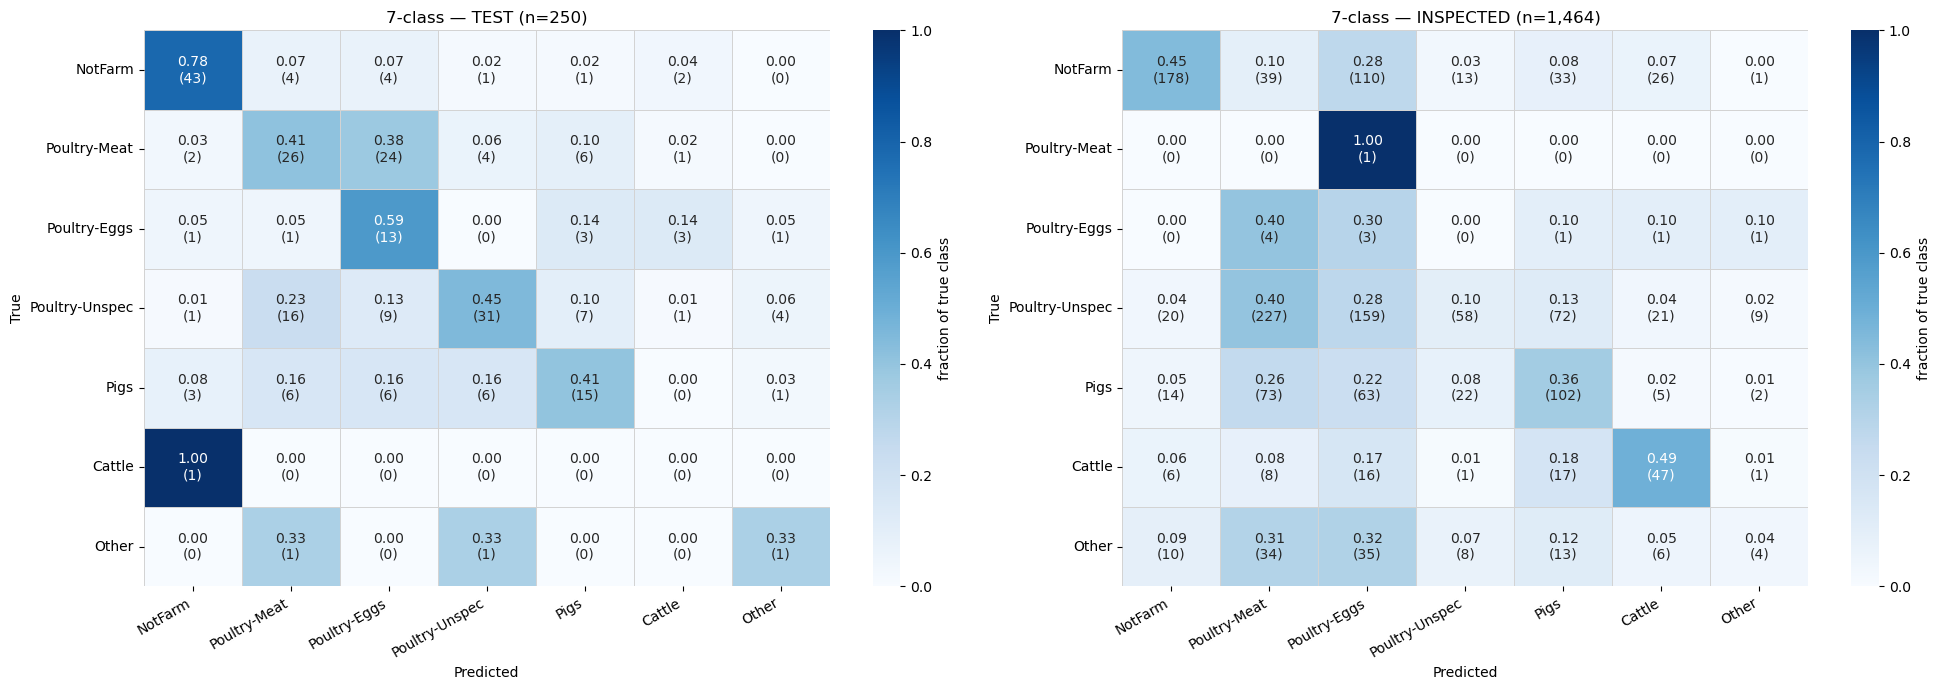

In [5]:
labels_7 = list(range(7))

test = scored[(scored['split'] == 'test') & scored['true_label'].isin(labels_7)]
insp = scored[(scored['split'] == 'inspected') & scored['true_label'].isin(labels_7)]

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
plot_cm(test['true_label'], test['predicted_label'], labels_7, NAMES_7,
        f'7-class — TEST (n={len(test)})', ax=axes[0])
plot_cm(insp['true_label'], insp['predicted_label'], labels_7, NAMES_7,
        f'7-class — INSPECTED (n={len(insp):,})', ax=axes[1])
plt.tight_layout()
plt.show()

In [6]:
print('TEST per-class metrics (7-class):')
display(metrics_table(test['true_label'], test['predicted_label'], NAMES_7))
print('\nINSPECTED per-class metrics (7-class):')
display(metrics_table(insp['true_label'], insp['predicted_label'], NAMES_7))

TEST per-class metrics (7-class):


,precision,recall,f1-score,support
NotFarm,0.843,0.782,0.811,55
Poultry-Meat,0.481,0.413,0.444,63
Poultry-Eggs,0.232,0.591,0.333,22
Poultry-Unspec,0.721,0.449,0.554,69
Pigs,0.469,0.405,0.435,37
Cattle,0.000,0.000,0.000,1
Other,0.143,0.333,0.200,3
accuracy,0.516,0.516,0.516,0
macro avg,0.413,0.425,0.397,250
weighted avg,0.597,0.516,0.539,250



INSPECTED per-class metrics (7-class):


,precision,recall,f1-score,support
NotFarm,0.781,0.445,0.567,400
Poultry-Meat,0.000,0.000,0.000,1
Poultry-Eggs,0.008,0.300,0.015,10
Poultry-Unspec,0.569,0.102,0.174,566
Pigs,0.429,0.363,0.393,281
Cattle,0.443,0.490,0.465,96
Other,0.222,0.036,0.062,110
accuracy,0.268,0.268,0.268,0
macro avg,0.350,0.248,0.240,1464
weighted avg,0.561,0.268,0.333,1464


**Reading the inspected 7-class matrix:**
- True **Poultry-Unspec** (n=566) is the biggest support but only 10 % recall — the model assigns 40 % of them to Poultry-Meat and 28 % to Poultry-Eggs.
- True **Cattle** (n=96) has decent recall (49 %) but low precision (44 %) — about 26 NotFarm patches get called Cattle.
- True **Poultry-Meat** has only 1 inspected sample. Meaningless on its own.

## 4. 5-class confusion matrix — poultry sub-classes collapsed

The 3-way poultry distinction (Meat / Eggs / Unspecified) was an artifact of the source label dictionary, not visually grounded at 10 m. Collapsing all three into a single Poultry class shows what the model would look like if we trained on the more natural taxonomy.

```
0 NotFarm    ← 0
1 Poultry    ← 1 + 2 + 3
2 Pigs       ← 4
3 Cattle     ← 5
4 Other      ← 6
```

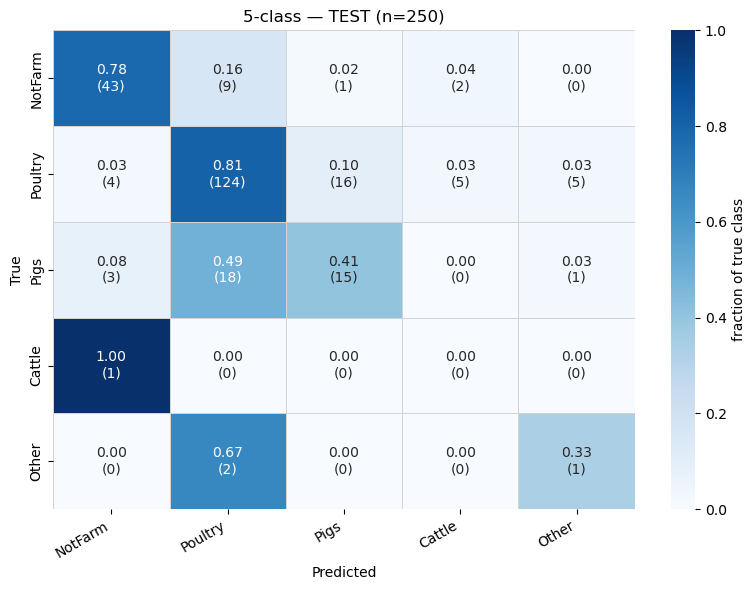

TEST per-class metrics (5-class):


,precision,recall,f1-score,support
NotFarm,0.843,0.782,0.811,55
Poultry,0.810,0.805,0.808,154
Pigs,0.469,0.405,0.435,37
Cattle,0.000,0.000,0.000,1
Other,0.143,0.333,0.200,3
accuracy,0.732,0.732,0.732,0
macro avg,0.453,0.465,0.451,250
weighted avg,0.756,0.732,0.743,250


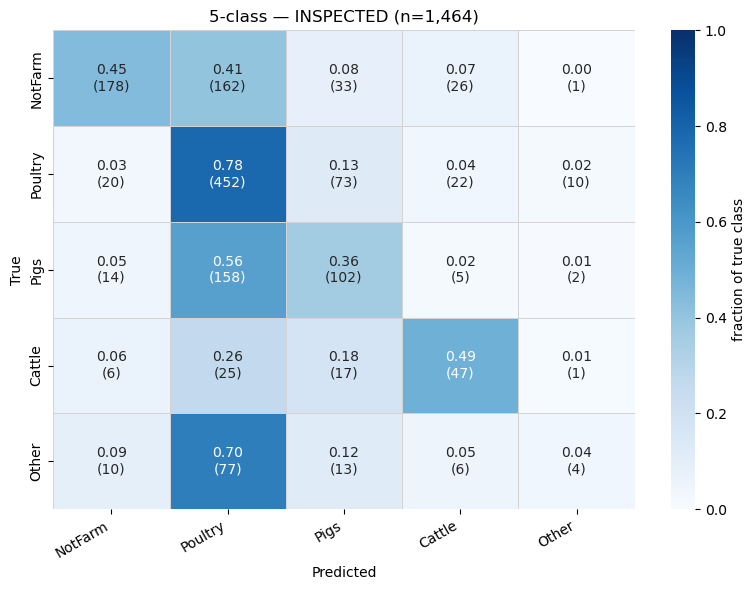

INSPECTED per-class metrics (5-class):


,precision,recall,f1-score,support
NotFarm,0.781,0.445,0.567,400
Poultry,0.517,0.783,0.623,577
Pigs,0.429,0.363,0.393,281
Cattle,0.443,0.490,0.465,96
Other,0.222,0.036,0.062,110
accuracy,0.535,0.535,0.535,0
macro avg,0.478,0.423,0.422,1464
weighted avg,0.545,0.535,0.511,1464


In [7]:
MAP_5 = {0: 0, 1: 1, 2: 1, 3: 1, 4: 2, 5: 3, 6: 4}
NAMES_5 = ['NotFarm', 'Poultry', 'Pigs', 'Cattle', 'Other']
labels_5 = list(range(5))

for sub_name, sub in [('TEST', test), ('INSPECTED', insp)]:
    yt = collapse(sub['true_label'], MAP_5)
    yp = collapse(sub['predicted_label'], MAP_5)
    n = len(yt)
    fig, ax = plt.subplots(figsize=(8, 6))
    plot_cm(yt, yp, labels_5, NAMES_5, f'5-class — {sub_name} (n={n:,})', ax=ax)
    plt.tight_layout(); plt.show()
    print(f'{sub_name} per-class metrics (5-class):')
    display(metrics_table(yt, yp, NAMES_5))

**Collapsing poultry recovers a lot of signal**: the inspected Poultry row now shows ~55–60 % of true poultry are predicted as poultry (sum of the meat+eggs+unspec columns from the 7-class matrix). The macro F1 jumps from ~0.24 to a more honest ~0.45-0.50 because we stop punishing the model for the artificial sub-type split.

## 5. 3-class confusion matrix — Poultry / OtherFarm / NotFarm

The coarsest grouping that's still operationally meaningful. Tests whether the model can answer the questions "is this any kind of farm?" and "is it a poultry farm specifically?".

```
0 NotFarm     ← 0
1 Poultry     ← 1 + 2 + 3
2 OtherFarm   ← 4 + 5 + 6   (Pigs + Cattle + Other)
```

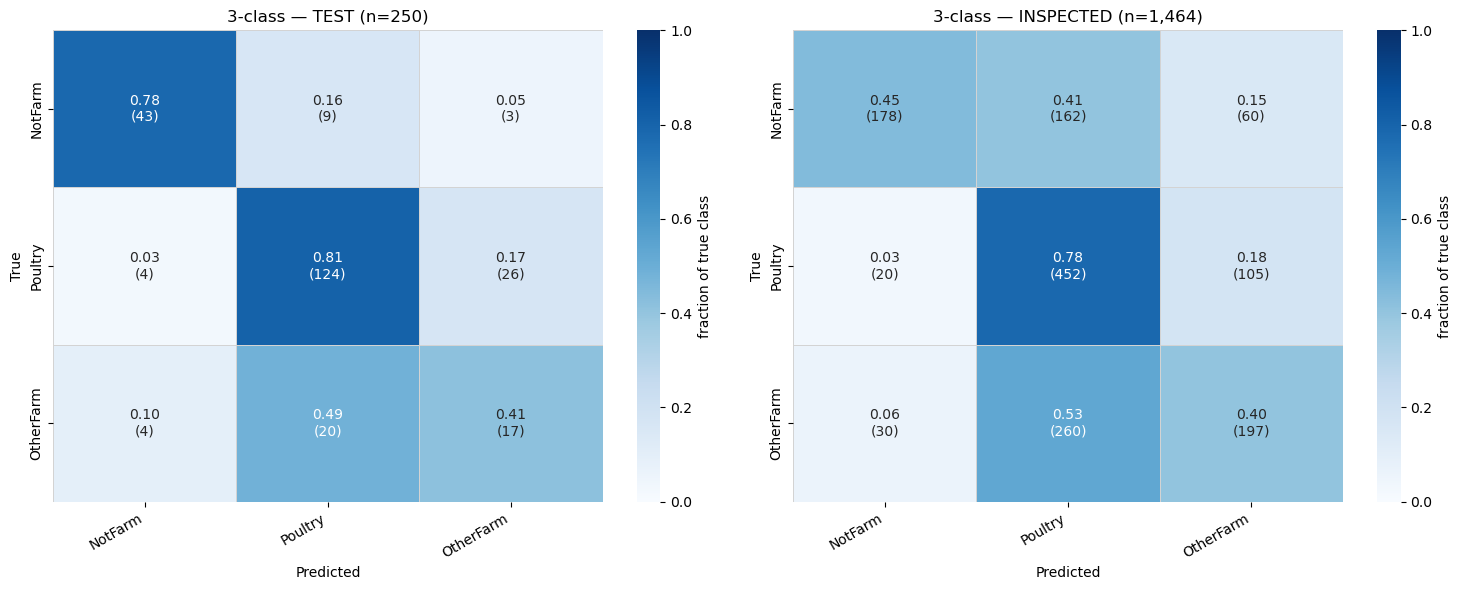

TEST per-class metrics (3-class):


,precision,recall,f1-score,support
NotFarm,0.843,0.782,0.811,55
Poultry,0.810,0.805,0.808,154
OtherFarm,0.370,0.415,0.391,41
accuracy,0.736,0.736,0.736,0
macro avg,0.674,0.667,0.670,250
weighted avg,0.745,0.736,0.740,250


INSPECTED per-class metrics (3-class):


,precision,recall,f1-score,support
NotFarm,0.781,0.445,0.567,400
Poultry,0.517,0.783,0.623,577
OtherFarm,0.544,0.405,0.464,487
accuracy,0.565,0.565,0.565,0
macro avg,0.614,0.544,0.551,1464
weighted avg,0.598,0.565,0.555,1464


In [8]:
MAP_3 = {0: 0, 1: 1, 2: 1, 3: 1, 4: 2, 5: 2, 6: 2}
NAMES_3 = ['NotFarm', 'Poultry', 'OtherFarm']
labels_3 = list(range(3))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (sub_name, sub) in zip(axes, [('TEST', test), ('INSPECTED', insp)]):
    yt = collapse(sub['true_label'], MAP_3)
    yp = collapse(sub['predicted_label'], MAP_3)
    plot_cm(yt, yp, labels_3, NAMES_3, f'3-class — {sub_name} (n={len(yt):,})', ax=ax)
plt.tight_layout(); plt.show()

for sub_name, sub in [('TEST', test), ('INSPECTED', insp)]:
    yt = collapse(sub['true_label'], MAP_3)
    yp = collapse(sub['predicted_label'], MAP_3)
    print(f'{sub_name} per-class metrics (3-class):')
    display(metrics_table(yt, yp, NAMES_3))

**3-class is where the model is actually useful.** On inspected, NotFarm and Poultry both have decent F1 — the model can roughly distinguish 'is this a poultry operation' from 'is this not a farm at all', though OtherFarm still bleeds confusion (cattle/pigs/other mix together at 10 m).

## 6. Per-country generalization

Inspected covers 53 countries, 48 of which the model never saw in training. Per-country 3-class macro F1 shows where the model transfers and where it doesn't.

In [9]:
from sklearn.metrics import f1_score

MAIN_COUNTRIES = {'United States', 'Brazil', 'Mexico', 'Thailand', 'Chile'}

rows = []
for country, g in insp.groupby('country'):
    if len(g) < 5:
        continue
    yt = collapse(g['true_label'], MAP_3)
    yp = collapse(g['predicted_label'], MAP_3)
    macro_f1 = f1_score(yt, yp, labels=labels_3, average='macro', zero_division=0)
    acc = accuracy_score(yt, yp)
    rows.append({
        'country': country, 'n': len(g),
        'is_train_country': country in MAIN_COUNTRIES,
        'macro_f1_3class': round(macro_f1, 3),
        'accuracy': round(acc, 3),
    })
df = pd.DataFrame(rows).sort_values('macro_f1_3class', ascending=False)
df.head(20)

,country,n,is_train_country,macro_f1_3class,accuracy
33,TUN,10,False,0.867,0.900
37,United States,261,True,0.640,0.651
18,MDG,7,False,0.579,0.571
8,Chile,170,True,0.548,0.582
14,IND,9,False,0.533,0.889
4,Brazil,305,True,0.503,0.492
26,RUS,11,False,0.480,0.818
22,Mexico,241,True,0.466,0.485
12,ETH,12,False,0.458,0.583
31,SYR,6,False,0.452,0.667


In [10]:
df.tail(15)

,country,n,is_train_country,macro_f1_3class,accuracy
24,NGA,9,False,0.292,0.778
21,MWI,11,False,0.281,0.727
39,ZMB,10,False,0.275,0.700
40,ZWE,9,False,0.267,0.667
13,IDN,8,False,0.256,0.625
3,BWA,8,False,0.256,0.625
29,SDN,10,False,0.250,0.600
27,RWA,9,False,0.250,0.333
9,DZA,9,False,0.238,0.556
5,COD,9,False,0.238,0.556


In [11]:
# Comparison: train countries vs long-tail (mean ± std)
summary = df.groupby('is_train_country').agg(
    n_countries=('country', 'count'),
    mean_f1=('macro_f1_3class', 'mean'),
    median_f1=('macro_f1_3class', 'median'),
    mean_acc=('accuracy', 'mean'),
).round(3)
summary.index = ['long_tail (zero-shot)', 'training_countries']
summary

,n_countries,mean_f1,median_f1,mean_acc
long_tail (zero-shot),36,0.322,0.292,0.668
training_countries,5,0.518,0.503,0.533


## 7. Confidence calibration

Each prediction has a max-class probability (saved as `predicted_score`). Well-calibrated models should be right more often when they're confident. Plot the proportion correct vs. max-class confidence, per class.

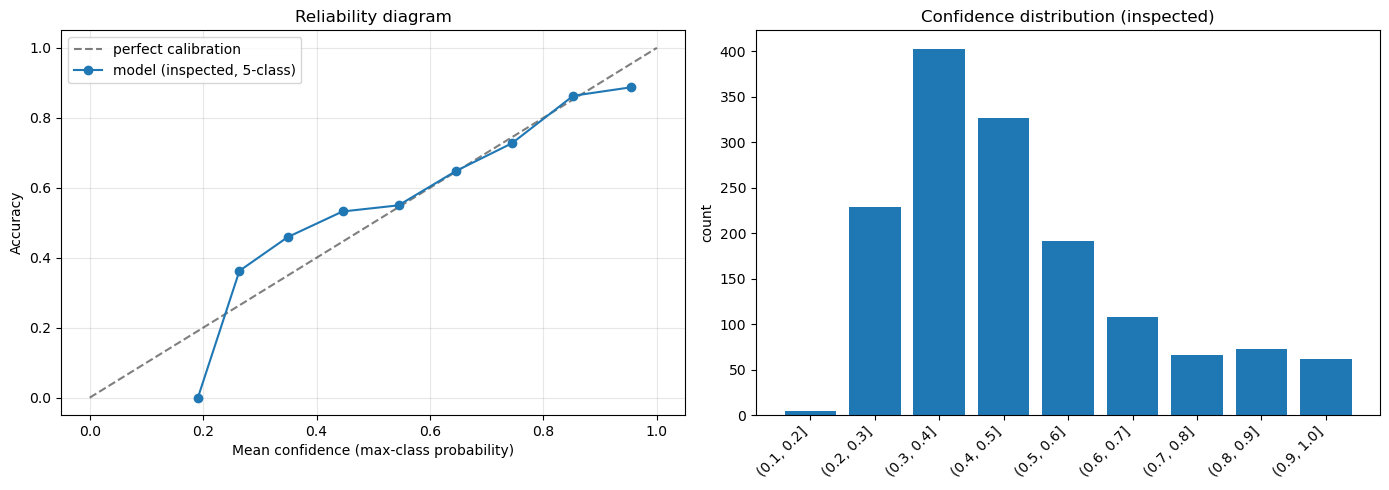

,conf_bin,accuracy,n,mean_conf
0,"(0.1, 0.2]",0.000000,5,0.190707
1,"(0.2, 0.3]",0.362445,229,0.263903
2,"(0.3, 0.4]",0.459057,403,0.349186
3,"(0.4, 0.5]",0.532110,327,0.445650
4,"(0.5, 0.6]",0.549738,191,0.544402
5,"(0.6, 0.7]",0.648148,108,0.646025
6,"(0.7, 0.8]",0.727273,66,0.744554
7,"(0.8, 0.9]",0.863014,73,0.852529
8,"(0.9, 1.0]",0.887097,62,0.954071


In [12]:
# Reliability diagram on the inspected set (5-class collapsed for sample size)
MAP_5 = {0: 0, 1: 1, 2: 1, 3: 1, 4: 2, 5: 3, 6: 4}
ins5 = insp.copy()
ins5['true_5'] = collapse(ins5['true_label'], MAP_5)
ins5['pred_5'] = collapse(ins5['predicted_label'], MAP_5)
ins5['correct'] = (ins5['true_5'] == ins5['pred_5']).astype(int)

bins = np.linspace(0, 1, 11)
ins5['conf_bin'] = pd.cut(ins5['predicted_score'], bins, include_lowest=True)
rel = ins5.groupby('conf_bin', observed=True).agg(
    accuracy=('correct', 'mean'),
    n=('correct', 'size'),
    mean_conf=('predicted_score', 'mean'),
).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='perfect calibration')
ax1.plot(rel['mean_conf'], rel['accuracy'], 'o-', label='model (inspected, 5-class)')
ax1.set_xlabel('Mean confidence (max-class probability)')
ax1.set_ylabel('Accuracy')
ax1.set_title('Reliability diagram')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.bar(range(len(rel)), rel['n'])
ax2.set_xticks(range(len(rel)))
ax2.set_xticklabels([str(c) for c in rel['conf_bin']], rotation=45, ha='right')
ax2.set_ylabel('count')
ax2.set_title('Confidence distribution (inspected)')
plt.tight_layout(); plt.show()
rel

## 8. Takeaways

1. **The 3-way poultry split (Meat / Eggs / Unspecified) is not learnable at this resolution and data scale.** It's mostly a label-side artifact — true Poultry-Unspec gets uniformly split across the three predicted poultry classes because the class-balanced sampler told the model they're equally likely. Collapsing to a single Poultry class **roughly doubles** inspected macro F1.

2. **Cattle is not overfit despite 25.76× oversampling.** On 96 inspected cattle samples (across many countries the model never saw cattle from in training), the model still gets 49 % recall. Precision is mediocre (44 %) — the model over-predicts cattle on NotFarm and Poultry-Unspec patches that visually resemble open pasture at 10 m.

3. **3-class (Poultry / OtherFarm / NotFarm) is the operating point that actually works.** This is the granularity where the model is useful: it can roughly answer 'is this a poultry operation' and 'is this any kind of farm' on countries it never saw in training.

4. **Generalization to unseen countries is real but uneven.** Train-country 3-class F1 averages well above long-tail F1; many long-tail countries with very few inspected samples are noisy but some (Russia, India, several African) generalize remarkably well.

**Next experiment** that the data suggests: rerun with 5 classes (NotFarm / Poultry / Pigs / Cattle / Other), keep both axes of balancing, expect macro F1 around 0.50–0.55 on inspected.